# MWE: the pixelised `Image` component

`virgil.models.Image` is a grid of pixels that behaves like any other source component. Its free parameters are log-brightnesses, and its pixel fluxes are their softmax over an optional support mask, so they are positive, sum to one, and are exactly zero outside the support. Its visibilities are the exact Fourier transform of the pixels, and it can sit in a `System` next to analytic components, such as a point-source star, with its own `flux` weight.

This notebook builds an image, checks it against analytic models whose answer is known, mixes it with a star, and takes the gradient of a likelihood with respect to every pixel. You should come away knowing how to make an `Image`, how it is oriented, and that it is ready to be fitted.

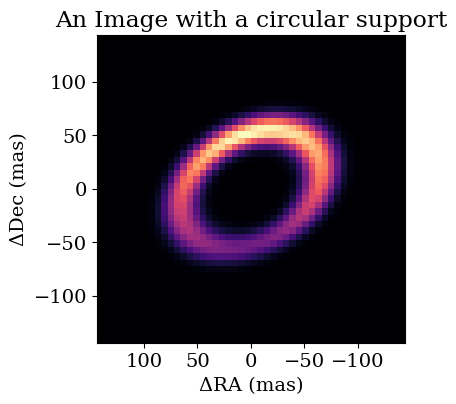

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp

from virgil import pixel_offsets
from virgil.likelihood import model_loglike
from virgil.models import (
    GaussianDisk,
    Image,
    PointSource,
    System,
    circular_support,
)
from virgil.oidata import OIData
from virgil.plotting import _enforce_sky_orientation, plot_model
from virgil.scenes import ring

npix, scale = 48, 6.0  # 288 mas field
support = circular_support(npix, scale, radius_mas=120.0)
envelope = Image.from_brightness(
    ring(npix, scale, 70.0, 12.0, inc_deg=45.0, pa_deg=120.0, asymmetry=0.5),
    scale,
    support=support,
    flux=0.3,
)
plot_model(
    envelope,
    fov_mas=npix * scale,
    npix=npix,
    title="An Image with a circular support",
)
plt.show()

## Orientation: one bright pixel is a point source

With all its flux in one pixel, an image is a point source at that pixel's offset. Row 0 is North and column 0 is East, as in `render`, so a pixel above and to the left of the centre has positive ΔRA and ΔDec. `pixel_offsets` gives the offset of each row or column, and the two models agree to float32 rounding.

In [2]:
row, col = 10, 14
one_pixel = Image(
    jnp.full((npix, npix), -jnp.inf).at[row, col].set(0.0), scale
)
offsets = pixel_offsets(npix, scale)
point = PointSource(dra=offsets[col], ddec=offsets[row])
rng = onp.random.default_rng(0)
u, v = rng.uniform(-6.5, 6.5, (2, 200))
difference = jnp.abs(
    one_pixel.model(u, v, 4.8e-6) - point.model(u, v, 4.8e-6)
).max()
print(
    f"pixel (row {row}, col {col}) is at dRA = {offsets[col]:+.0f} mas, dDec = {offsets[row]:+.0f} mas"
)
print(f"largest |V_image - V_point| over 200 baselines: {difference:.1e}")

pixel (row 10, col 14) is at dRA = +57 mas, dDec = +81 mas
largest |V_image - V_point| over 200 baselines: 1.0e-06


## A pixelised Gaussian is a Gaussian

`Image.from_model` samples any virgil model onto the pixel grid, which is how a parametric fit will start an image reconstruction. Sampling a Gaussian disk and transforming the pixels should give back the analytic visibility, up to a small pixelisation error that shrinks as the pixels get smaller than the source.

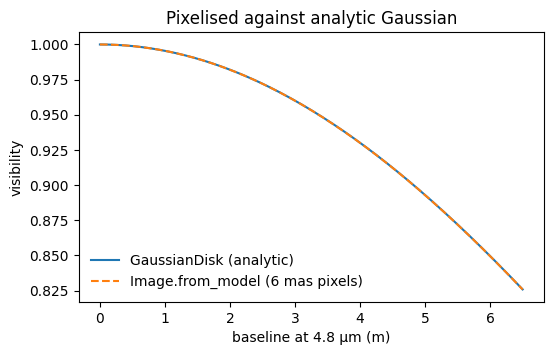

In [3]:
disk = GaussianDisk(sigma=15.0)
pixelised = Image.from_model(disk, npix, scale)
baseline = jnp.linspace(0.0, 6.5, 200)
analytic = disk.model(baseline, 0 * baseline, 4.8e-6).real
from_pixels = pixelised.model(baseline, 0 * baseline, 4.8e-6).real

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(baseline, analytic, label="GaussianDisk (analytic)")
ax.plot(baseline, from_pixels, "--", label="Image.from_model (6 mas pixels)")
ax.set(
    xlabel="baseline at 4.8 µm (m)",
    ylabel="visibility",
    title="Pixelised against analytic Gaussian",
)
ax.legend(frameon=False)
plt.show()

## Mixing with an analytic star

In a `System`, each component's visibility is weighted by its flux. Here the ring image carries 30% of the star's flux, and the star stays analytic (unresolved things stay analytic; resolved emission goes in pixels). The squared visibility drops from one at zero baseline to the star's share of the flux once the ring is resolved.

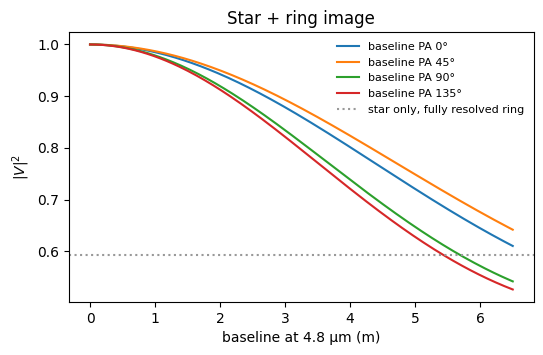

In [4]:
scene = System(star=PointSource(), env=envelope)
angles = jnp.linspace(0.0, jnp.pi, 4, endpoint=False)
fig, ax = plt.subplots(figsize=(6, 3.5))
for angle in angles:
    uu, vv = baseline * jnp.sin(angle), baseline * jnp.cos(angle)
    v2 = jnp.abs(scene.model(uu, vv, 4.8e-6)) ** 2
    ax.plot(baseline, v2, label=f"baseline PA {jnp.degrees(angle):.0f}°")
ax.axhline(
    (1 / 1.3) ** 2, color="0.6", ls=":", label="star only, fully resolved ring"
)
ax.set(
    xlabel="baseline at 4.8 µm (m)",
    ylabel=r"$|V|^2$",
    title="Star + ring image",
)
ax.legend(frameon=False, fontsize=8)
plt.show()

## Gradients with respect to every pixel

Image reconstruction needs the gradient of the likelihood with respect to all the pixels at once. Here we simulate closure-phase and V² data for the scene on the ν Hor AMI coverage in the repository, then evaluate the log-likelihood of a slightly different image and take its gradient with `jax.grad`. The gradient is a map with the image's shape, and is exactly zero outside the support.

W0930 22:29:17.020881 9846354 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


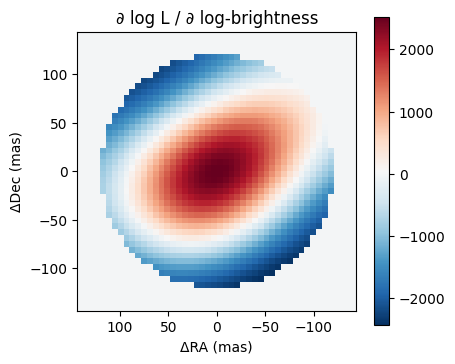

In [5]:
template = OIData(str(root / "data" / "NuHor_F480M.oifits"))
data = template.with_model(scene, key=jax.random.PRNGKey(1))
start = scene.set("env.log_brightness", jnp.where(support, 0.0, -jnp.inf))


def loglike(log_brightness):
    return model_loglike(start.set("env.log_brightness", log_brightness), data)


gradient = jax.grad(loglike)(start.env.log_brightness)
fig, ax = plt.subplots(figsize=(4.5, 4))
extent = npix * scale / 2 * onp.array([1, -1, -1, 1])
image = ax.imshow(gradient, extent=extent, origin="upper", cmap="RdBu_r")
_enforce_sky_orientation(ax)
ax.set(
    xlabel="ΔRA (mas)", ylabel="ΔDec (mas)", title="∂ log L / ∂ log-brightness"
)
fig.colorbar(image, ax=ax)
plt.show()

## Summary

An `Image` is a positive, unit-sum pixel grid with an optional support, oriented East left and North up like every other virgil image. Its visibilities are exact (a single pixel reproduces a point source to float32 rounding, and a pixelised Gaussian matches the analytic one), it mixes with analytic components in a `System`, and the likelihood is differentiable with respect to every pixel. That is everything the fitting stage needs.